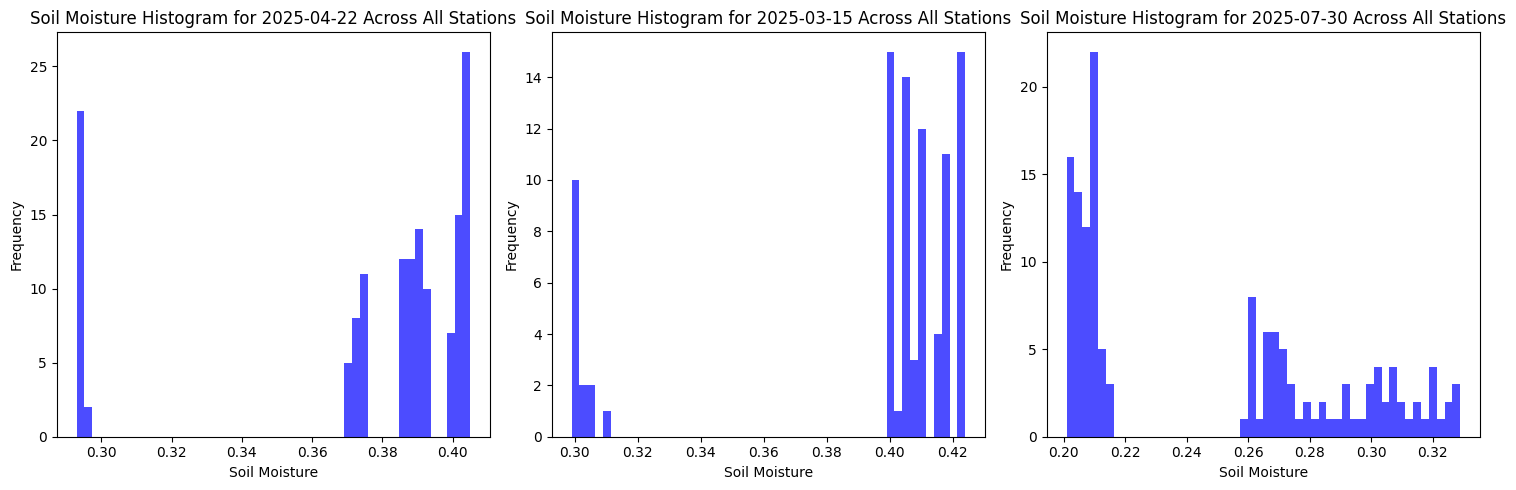

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

# Get all STM files
file_paths = glob.glob('TERENO_TERENO_Schoeneseiffen_sm_*.stm')

# Load one file to get unique dates
sample_df = pd.read_csv(file_paths[0], sep=r'\s+', skiprows=1, header=None, names=['date', 'time', 'soil_moisture', 'flag', 'source'])
sample_df['datetime'] = pd.to_datetime(sample_df['date'] + ' ' + sample_df['time'], format='%Y/%m/%d %H:%M')
sample_df.set_index('datetime', inplace=True)
sample_df = sample_df[sample_df['flag'] == 'G']
unique_dates = np.unique(sample_df.index.date)

# Select three random dates
np.random.seed(42)  # For reproducibility
selected_dates = np.random.choice(unique_dates, 3, replace=False)

# Collect data for each selected date across all files
data_per_date = {date: [] for date in selected_dates}

for file_path in file_paths:
    # Load the data
    df = pd.read_csv(file_path, sep=r'\s+', skiprows=1, header=None, names=['date', 'time', 'soil_moisture', 'flag', 'source'])
    
    # Combine date and time
    df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='%Y/%m/%d %H:%M')
    df.set_index('datetime', inplace=True)
    
    # Filter valid data
    df = df[df['flag'] == 'G']
    
    # Collect data for selected dates
    for date in selected_dates:
        mask = df.index.date == date
        daily_data = df[mask]['soil_moisture']
        data_per_date[date].extend(daily_data.tolist())

# Plot histograms for each selected date
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, date in enumerate(selected_dates):
    axes[i].hist(data_per_date[date], bins=50, alpha=0.7, color='blue')
    axes[i].set_title(f'Soil Moisture Histogram for {date} Across All Stations')
    axes[i].set_xlabel('Soil Moisture')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

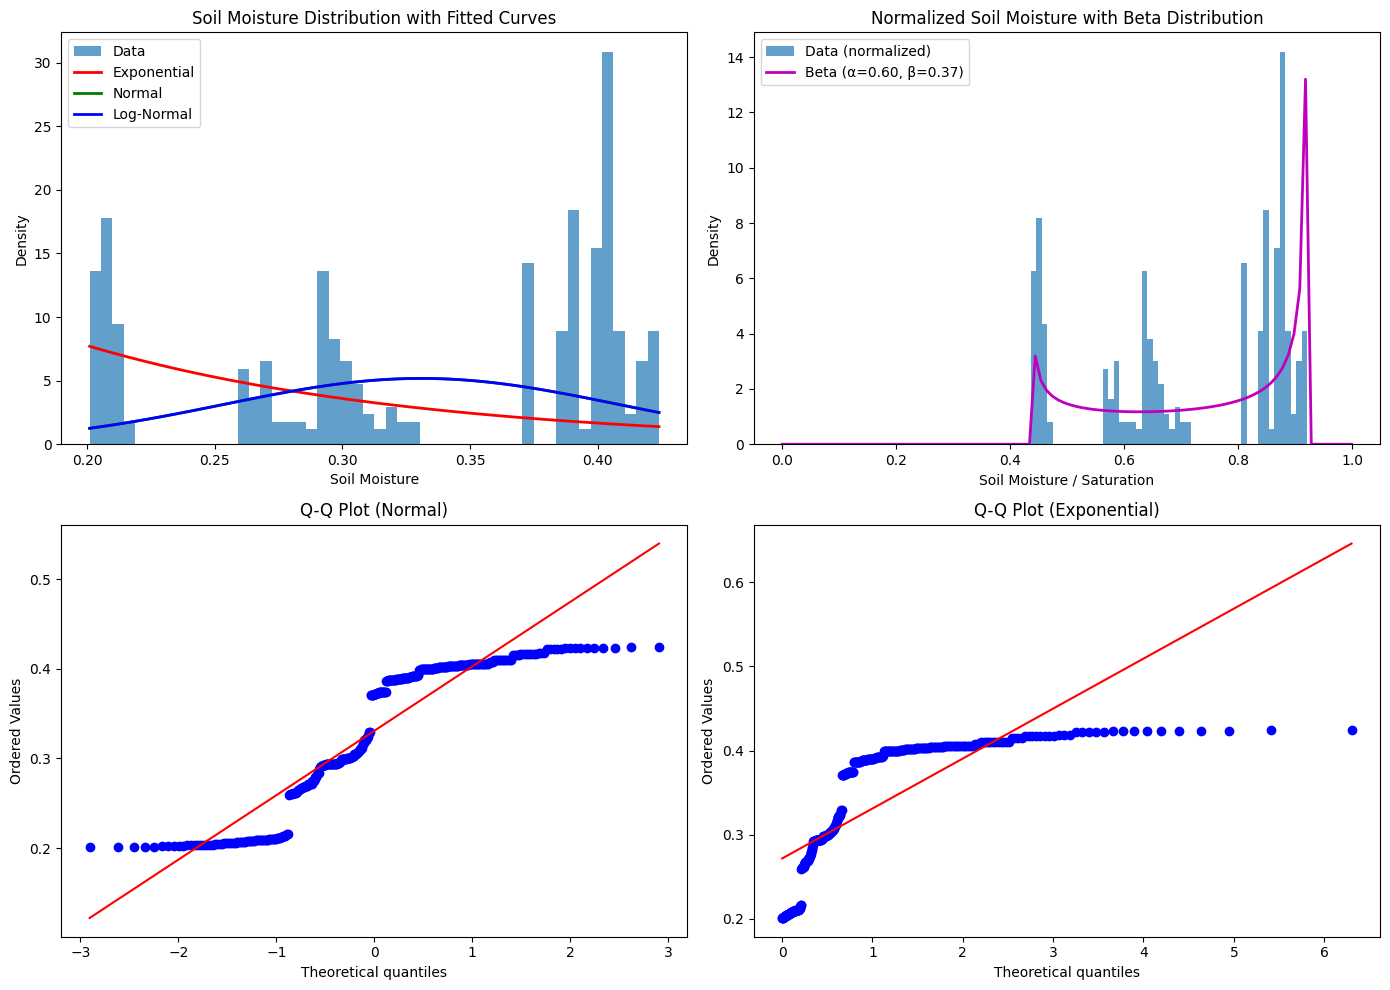

=== Kolmogorov-Smirnov Tests ===
Exponential: statistic=0.2458, p-value=1.3500e-20
Normal: statistic=0.2151, p-value=7.9341e-16
Log-Normal: statistic=0.2151, p-value=7.9335e-16
Beta (normalized): statistic=0.1952, p-value=4.2825e-13

(Plus la p-value est élevée, meilleur est le fit)


In [13]:
from scipy import stats
from scipy.stats import expon, norm, lognorm, beta

# Combine all data for analysis
all_data = np.concatenate([data_per_date[date] for date in selected_dates])

# Normalize data to [0, 1] for beta distribution (using saturation value from static file)
saturation = 0.46
all_data_normalized = all_data / saturation
all_data_normalized = np.clip(all_data_normalized, 0.001, 0.999)  # Avoid edge issues for beta

# Fit different distributions
# Exponential
exp_params = expon.fit(all_data)
# Normal
norm_params = norm.fit(all_data)
# Log-normal
lognorm_params = lognorm.fit(all_data)
# Beta (on normalized data)
beta_params = beta.fit(all_data_normalized)

# Create x values for plotting
x = np.linspace(min(all_data), max(all_data), 100)
x_norm = np.linspace(0.001, 0.999, 100)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram with fitted distributions
ax = axes[0, 0]
ax.hist(all_data, bins=50, density=True, alpha=0.7, label='Data')
ax.plot(x, expon.pdf(x, *exp_params), 'r-', lw=2, label=f'Exponential')
ax.plot(x, norm.pdf(x, *norm_params), 'g-', lw=2, label=f'Normal')
ax.plot(x, lognorm.pdf(x, *lognorm_params), 'b-', lw=2, label=f'Log-Normal')
ax.set_title('Soil Moisture Distribution with Fitted Curves')
ax.set_xlabel('Soil Moisture')
ax.set_ylabel('Density')
ax.legend()

# Beta distribution on normalized data
ax = axes[0, 1]
ax.hist(all_data_normalized, bins=50, density=True, alpha=0.7, label='Data (normalized)')
ax.plot(x_norm, beta.pdf(x_norm, *beta_params), 'm-', lw=2, label=f'Beta (α={beta_params[0]:.2f}, β={beta_params[1]:.2f})')
ax.set_title('Normalized Soil Moisture with Beta Distribution')
ax.set_xlabel('Soil Moisture / Saturation')
ax.set_ylabel('Density')
ax.legend()

# Q-Q plots
ax = axes[1, 0]
stats.probplot(all_data, dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Normal)')

ax = axes[1, 1]
stats.probplot(all_data, dist="expon", plot=ax)
ax.set_title('Q-Q Plot (Exponential)')

plt.tight_layout()
plt.show()

# Kolmogorov-Smirnov tests
print("=== Kolmogorov-Smirnov Tests ===")
print(f"Exponential: statistic={stats.kstest(all_data, 'expon', exp_params).statistic:.4f}, p-value={stats.kstest(all_data, 'expon', exp_params).pvalue:.4e}")
print(f"Normal: statistic={stats.kstest(all_data, 'norm', norm_params).statistic:.4f}, p-value={stats.kstest(all_data, 'norm', norm_params).pvalue:.4e}")
print(f"Log-Normal: statistic={stats.kstest(all_data, 'lognorm', lognorm_params).statistic:.4f}, p-value={stats.kstest(all_data, 'lognorm', lognorm_params).pvalue:.4e}")
print(f"Beta (normalized): statistic={stats.kstest(all_data_normalized, 'beta', beta_params).statistic:.4f}, p-value={stats.kstest(all_data_normalized, 'beta', beta_params).pvalue:.4e}")
print("\n(Plus la p-value est élevée, meilleur est le fit)")

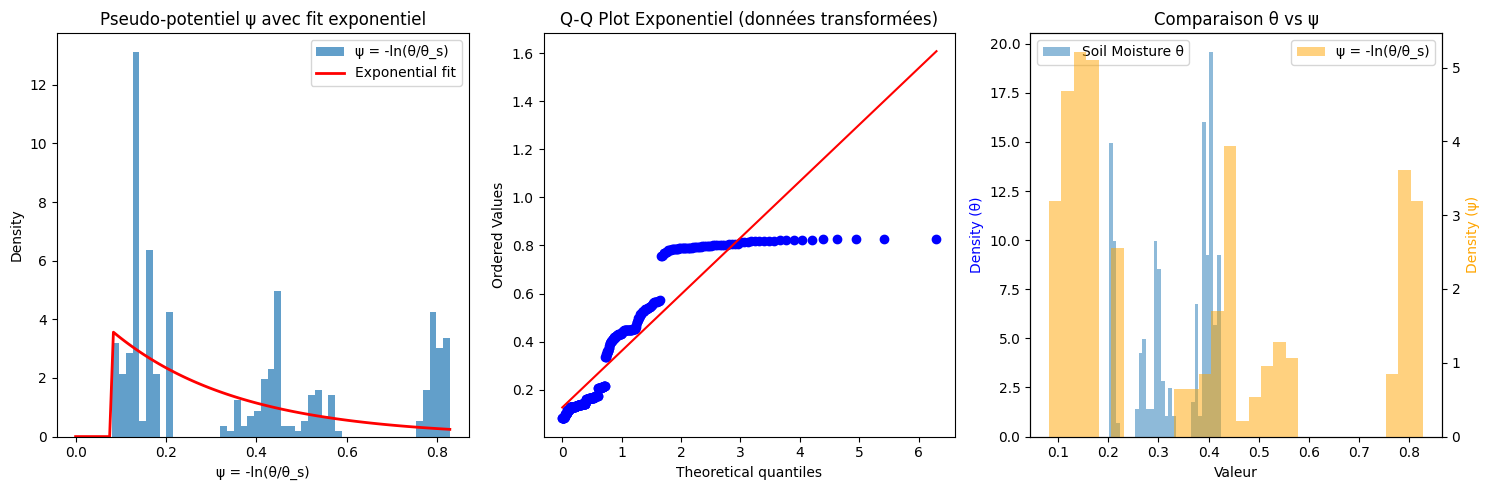

=== Test KS pour la distribution exponentielle sur ψ ===
Statistic: 0.1664
P-value: 1.2975e-09

Interprétation: ❌ Ne suit pas parfaitement une exponentielle


In [14]:
# Transformation vers pseudo-potentiel (devrait suivre une exponentielle)
# ψ = -ln(θ / θ_s) où θ = soil moisture et θ_s = saturation

saturation = 0.46

# Éviter les valeurs nulles ou négatives pour le log
all_data_clipped = np.clip(all_data, 0.001, saturation - 0.001)

# Transformation
psi = -np.log(all_data_clipped / saturation)

# Fit exponentielle sur les données transformées
exp_params_psi = expon.fit(psi)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogramme des données transformées avec fit exponentiel
ax = axes[0]
ax.hist(psi, bins=50, density=True, alpha=0.7, label='ψ = -ln(θ/θ_s)')
x_psi = np.linspace(0, max(psi), 100)
ax.plot(x_psi, expon.pdf(x_psi, *exp_params_psi), 'r-', lw=2, label=f'Exponential fit')
ax.set_title('Pseudo-potentiel ψ avec fit exponentiel')
ax.set_xlabel('ψ = -ln(θ/θ_s)')
ax.set_ylabel('Density')
ax.legend()

# Q-Q plot pour exponentielle
ax = axes[1]
stats.probplot(psi, dist="expon", plot=ax)
ax.set_title('Q-Q Plot Exponentiel (données transformées)')

# Comparaison avant/après transformation
ax = axes[2]
ax.hist(all_data, bins=30, density=True, alpha=0.5, label='Soil Moisture θ')
ax2 = ax.twinx()
ax2.hist(psi, bins=30, density=True, alpha=0.5, color='orange', label='ψ = -ln(θ/θ_s)')
ax.set_xlabel('Valeur')
ax.set_ylabel('Density (θ)', color='blue')
ax2.set_ylabel('Density (ψ)', color='orange')
ax.set_title('Comparaison θ vs ψ')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Test KS pour exponentielle
ks_stat, ks_pvalue = stats.kstest(psi, 'expon', exp_params_psi)
print(f"=== Test KS pour la distribution exponentielle sur ψ ===")
print(f"Statistic: {ks_stat:.4f}")
print(f"P-value: {ks_pvalue:.4e}")
print(f"\nInterprétation: {'✅ Bon fit exponentiel!' if ks_pvalue > 0.05 else '❌ Ne suit pas parfaitement une exponentielle'}")

In [ ]:
import sys
import pickle

# Path setup — same convention as other experiment scripts
sys.path.append("../src")
# from src.plot.classification_plots import (
#     plot_class_pair_barycenters,
#     plot_all_class_barycenters_grid,
# )


In [8]:
pkl_path = "/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/src/results/regime_classification/one-shot/experiment_data.pkl"
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

results        = data['results']
X_train_raw    = data['X_train_raw']
X_train_params = data['X_train_params']
Y_train        = data['Y_train']
idx_to_regime  = data['idx_to_regime']


In [158]:
import numpy as np
from scipy import stats

In [93]:
print(f"X_train_raw    : {len(X_train_raw)} éléments")
print(f"X_train_raw[0] : type={type(X_train_raw[0])}, shape={np.array(X_train_raw[0]).shape}")
print(f"X_train_params : {len(X_train_params)} éléments")
print(f"X_train_params[0] : type={type(X_train_params[0])}, shape={np.array(X_train_params[0]).shape}")
print(f"Y_train        : shape={Y_train.shape}, classes={np.unique(Y_train)}")

X_train_raw    : 600 éléments
X_train_raw[0] : type=<class 'numpy.ndarray'>, shape=(365, 64)
X_train_params : 600 éléments
X_train_params[0] : type=<class 'numpy.ndarray'>, shape=(365, 1)
Y_train        : shape=(600,), classes=[0 1 2 3 4]


In [48]:
from scipy import stats
import pandas as pd
df = []
for i in range(len(X_train_raw)):
    for j in range(len(X_train_raw[i])):
        x = X_train_raw[i][j].ravel()
        lam = 1 / np.mean(x)  # Estimation du paramètre lambda
        D, p = stats.kstest(x, 'expon', args=(0, 1/lam))
        # print("lambda =", lam)
        if p > 0.05:
            # print(f"Sample {i}, feature {j} and class {Y_train[i]} follows an exponential distribution (p-value = {p:.4f})")
            df.append((i, j, Y_train[i], p))

df = pd.DataFrame(df, columns=['Sample', 'Feature', 'Class', 'P-Value'])
filtered_df = df[df['P-Value'] > 0.05]
print(f"{len(filtered_df)} features follow an exponential distribution with p-value > 0.05")


/tmp/ipykernel_45515/1408129518.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  lam = 1 / np.mean(x)  # Estimation du paramètre lambda
/home/mgallet/Documents/Codes/Python/3_DEVELOPPEMENT/WaSPS-DTW/WaSPS-DTW/venv/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2159: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


5080 features follow an exponential distribution with p-value > 0.05


In [50]:
df = pd.DataFrame(df, columns=['Sample', 'Feature', 'Class', 'P-Value'])
filtered_df = df[df['P-Value'] > 0.05]
print(f"{len(filtered_df)}/{365*len(Y_train)} features follow an exponential distribution with p-value > 0.05")


5080/219000 features follow an exponential distribution with p-value > 0.05


(array([36.,  4.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  2.,  2.,  0.,  2.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  2.,  0.,  3.,  0.,  1.,  2.,  0.,  3.]),
 array([0.        , 0.0099707 , 0.01994141, 0.02991211, 0.03988281,
        0.04985352, 0.05982422, 0.06979492, 0.07976563, 0.08973633,
        0.09970703, 0.10967773, 0.11964844, 0.12961914, 0.13958984,
        0.14956055, 0.15953125, 0.16950195, 0.17947266, 0.18944336,
        0.19941406, 0.20938477, 0.21935547, 0.22932617, 0.23929688,
        0.24926758, 0.25923828, 0.26920898, 0.27917969, 0.28915039,
        0.29912109, 0.3090918 , 0.3190625 , 0.3290332 , 0.33900391,
        0.34897461, 0.35894531, 0.36891602, 0.37888672, 0.38885742,
        0.39882813, 0.40879883, 0.41876953, 0.42874023, 0.43871094,
        0.44868164, 0.45865234, 0.46862305, 0.47859375, 0.48856445,
        0.49853516]),
 <BarContainer

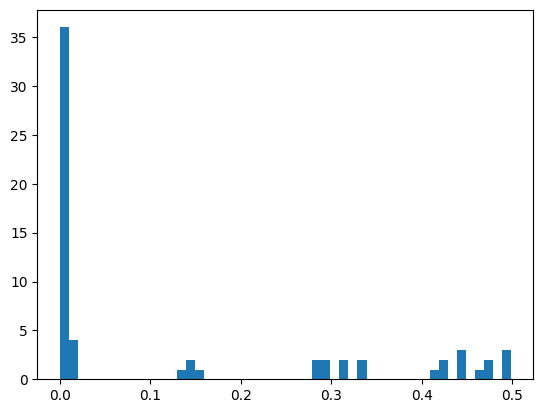

In [43]:
# X_train_raw[0]
import matplotlib.pyplot as plt
# for i in range(len(X_train_raw)):
plt.hist(X_train_raw[4][2].ravel(), bins=50)

# Exploration : impact de window_size et time_window sur l'appartenance à la loi exponentielle

Pour la première station (A105003001), on extrait des échantillons avec différentes combinaisons de `window_size` et `time_window` et on teste si les valeurs suivent une loi exponentielle.

In [112]:
import sys
import importlib.util
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# Robust repo root detection from notebook context
cwd = Path.cwd().resolve()
repo_root_candidates = [cwd, cwd.parent]
repo_root = None
for cand in repo_root_candidates:
    target = cand / "src" / "data_generator" / "Explore_2_dataset" / "build_classification_dataset.py"
    if target.exists():
        repo_root = cand
        break

if repo_root is None:
    raise FileNotFoundError("Impossible de localiser src/data_generator/Explore_2_dataset/build_classification_dataset.py")

sys.path.insert(0, str(repo_root / "src"))

# Import module directly from file to avoid broken package-level imports in data_generator/__init__.py
module_path = repo_root / "src" / "data_generator" / "Explore_2_dataset" / "build_classification_dataset.py"
spec = importlib.util.spec_from_file_location("build_classification_dataset", module_path)
build_ds = importlib.util.module_from_spec(spec)
spec.loader.exec_module(build_ds)

lambert93_to_wgs84 = build_ds.lambert93_to_wgs84
find_nearest_pixel = build_ds.find_nearest_pixel
extract_window = build_ds.extract_window

# ── Chemins ──────────────────────────────────────────────────────────────────
NC_PATH = "/home/mgallet/Documents/Dataset/RIVER_DISCHARGES/c7491e060d94c97212f0fe7ebcff57f0/data_version-5.nc"
CSV_PATH = str(repo_root / "src" / "data_generator" / "Explore_2_dataset" / "stations_regimes_explore2.csv")

# ── Première station ─────────────────────────────────────────────────────────
df_stations = pd.read_csv(CSV_PATH)
df_stations = df_stations.dropna(subset=["X_Lambert93", "Y_Lambert93", "regime_code"])
station = df_stations.iloc[0]
print(f"Station : {station['code_station']}  —  {station['nom_station']}")
print(f"Régime  : {station['regime_code']}")
print(f"Lambert93 : ({station['X_Lambert93']:.0f}, {station['Y_Lambert93']:.0f})")

lon, lat = lambert93_to_wgs84(station["X_Lambert93"], station["Y_Lambert93"])
print(f"WGS84     : lon={lon:.4f}, lat={lat:.4f}")

# ── Chargement NetCDF ────────────────────────────────────────────────────────
ds = xr.open_dataset(NC_PATH, engine="netcdf4")
data = ds["dis06"].values
lat_coords = ds["latitude"].values
lon_coords = ds["longitude"].values
print(f"\nDonnées NetCDF : shape={data.shape}")
print(f"  time  : {data.shape[0]} pas")
print(f"  lat   : {lat_coords.min():.2f} -> {lat_coords.max():.2f}")
print(f"  lon   : {lon_coords.min():.2f} -> {lon_coords.max():.2f}")

lat_idx, lon_idx = find_nearest_pixel(lat, lon, lat_coords, lon_coords)
print(f"\nPixel le plus proche : lat_idx={lat_idx}, lon_idx={lon_idx}")
print(f"  Coordonnées du pixel : lat={lat_coords[lat_idx]:.4f}, lon={lon_coords[lon_idx]:.4f}")

# Série temporelle du pixel central (un seul pixel, toutes les étapes de temps)
ts_center = data[:, lat_idx, lon_idx]
ts_valid = ts_center[~np.isnan(ts_center)]
print(f"\nSérie temporelle (pixel central) : {len(ts_valid)} valeurs valides sur {len(ts_center)}")
print(f"  min={ts_valid.min():.3f}, max={ts_valid.max():.3f}, mean={ts_valid.mean():.3f}")

Station : A105003001  —  L Ill a Altkirch
Régime  : PC
Lambert93 : (1018591, 6733545)
WGS84     : lon=7.2439, lat=47.6252

Données NetCDF : shape=(1460, 660, 900)
  time  : 1460 pas
  lat   : 41.01 -> 51.99
  lon   : -5.99 -> 8.99

Pixel le plus proche : lat_idx=262, lon_idx=794
  Coordonnées du pixel : lat=47.6249, lon=7.2417

Série temporelle (pixel central) : 1460 valeurs valides sur 1460
  min=0.116, max=11.467, mean=1.534


In [138]:
def ks_pass_rate(data, lat_idx, lon_idx, window_size, time_window, alpha=0.05):
    """
    Pour une station donnée, extrait la fenêtre complète puis teste chaque
    groupe temporel (axe T) : est-ce que les D*W*W valeurs suivent une exp ?
    Retourne le taux de groupes qui passent le test KS.
    """
    window = extract_window(data, lat_idx, lon_idx, window_size, time_window)
    if window is None:
        return np.nan, 0, 0

    T = window.shape[0]
    passed = 0
    tested = 0
    p_values = []

    for t in range(T):
        x = window[t].ravel()
        x = x[~np.isnan(x)]
        x = x[x > 10*x.min()]  # Exclure les valeurs nulles ou négatives pour le test exponentiel
        if len(x) < 5:
            continue
        x = x - x.min()
        lam = 1.0 / np.mean(x)
        _, p = stats.kstest(x, 'expon', args=(0, 1.0 / lam))
        tested += 1
        if p > alpha:
            passed += 1
            p_values.append(p)


    # rate = passed / tested if tested > 0 else np.nan
    # rate est la moyenne des p
    rate = np.mean(p_values) if p_values else np.nan
    return rate, passed, tested,x


# ── Grille de paramètres ─────────────────────────────────────────────────────
window_sizes  = [2,3,4,8]
time_windows  = [2,4,8,16, 32]

rates = np.full((len(window_sizes), len(time_windows)), np.nan)

for i, ws in enumerate(window_sizes):
    for j, tw in enumerate(time_windows):
        # plt.figure(figsize=(6, 4))
        # plt.title(f"Station {station['code_station']} - ws={ws}, tw={tw}")
        rate, passed, tested,x = ks_pass_rate(data, lat_idx, lon_idx, ws, tw)
        # plt.hist(x, bins=30, alpha=0.7, color='blue')
        # plt.xlabel('Discharge')
        # plt.ylabel('Frequency')
        # plt.grid()
        # plt.show()
        rates[i, j] = rate
        print(f"  ws={ws:2d}, tw={tw:2d} → {passed:4d}/{tested:4d}  ({100*rate:.1f}%)")

print("\nFait.")


  ws= 2, tw= 2 →    2/   3  (11.5%)
  ws= 2, tw= 4 →  355/ 365  (69.6%)
  ws= 2, tw= 8 →  155/ 182  (62.5%)
  ws= 2, tw=16 →   56/  91  (49.5%)
  ws= 2, tw=32 →   13/  45  (31.6%)
  ws= 3, tw= 2 →  717/ 730  (42.5%)
  ws= 3, tw= 4 →  330/ 365  (32.1%)
  ws= 3, tw= 8 →   94/ 182  (38.3%)
  ws= 3, tw=16 →   25/  91  (25.7%)
  ws= 3, tw=32 →    1/  45  (16.2%)
  ws= 4, tw= 2 →  601/ 730  (43.4%)
  ws= 4, tw= 4 →  142/ 365  (21.0%)
  ws= 4, tw= 8 →   14/ 182  (25.0%)
  ws= 4, tw=16 →    4/  91  (39.5%)
  ws= 4, tw=32 →    1/  45  (42.2%)
  ws= 8, tw= 2 →   36/ 730  (16.7%)
  ws= 8, tw= 4 →    4/ 365  (14.9%)
  ws= 8, tw= 8 →    0/ 182  (nan%)
  ws= 8, tw=16 →    0/  91  (nan%)
  ws= 8, tw=32 →    0/  45  (nan%)

Fait.


ValueError: 1 is not in list

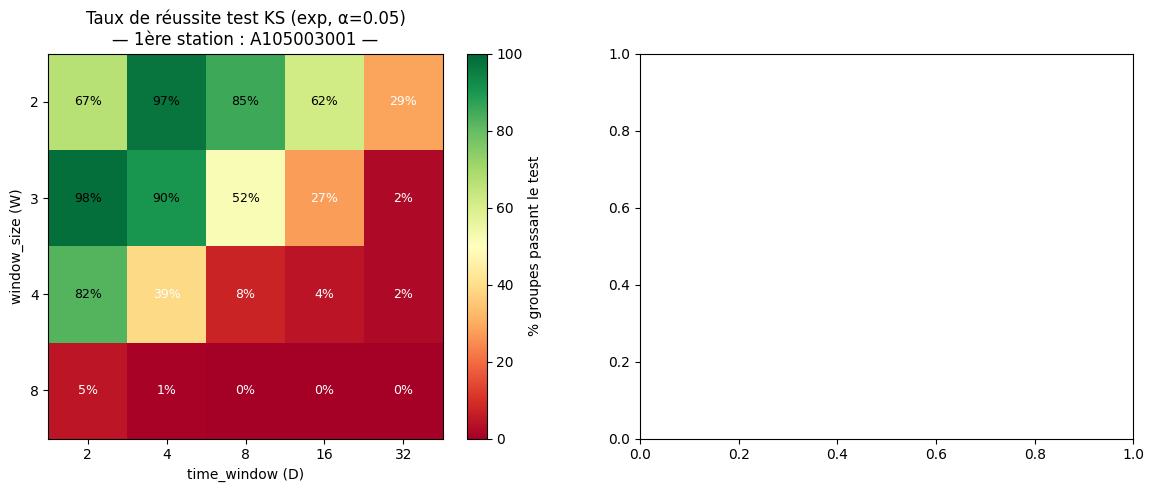

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Heatmap taux de réussite ─────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(rates * 100, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100,
               origin='upper')
ax.set_xticks(range(len(time_windows)))
ax.set_xticklabels(time_windows)
ax.set_yticks(range(len(window_sizes)))
ax.set_yticklabels(window_sizes)
ax.set_xlabel("time_window (D)")
ax.set_ylabel("window_size (W)")
ax.set_title(f"Taux de réussite test KS (exp, α=0.05)\n— 1ère station : {station['code_station']} —")
for i in range(len(window_sizes)):
    for j in range(len(time_windows)):
        v = rates[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{100*v:.0f}%", ha='center', va='center', fontsize=9,
                    color='white' if v < 0.4 else 'black')
plt.colorbar(im, ax=ax, label='% groupes passant le test')

# ── Profils selon chaque axe (ws=1 → impact temporel pur ; tw=1 → spatial pur) ──
ax = axes[1]
# Impact spatial pur : tw=1, faire varier ws
idx_tw1 = time_windows.index(1)
ax.plot(window_sizes, rates[:, idx_tw1] * 100, 'o-', label='time_window=1 (impact spatial)')
# Impact temporel pur : ws=1, faire varier tw
idx_ws1 = window_sizes.index(1)
ax.plot(time_windows, rates[idx_ws1, :] * 100, 's--', label='window_size=1 (impact temporel)',
        color='orange')
ax.axhline(5, color='gray', linestyle=':', label='seuil α=5 % (hasard)')
ax.set_xlabel("Taille de la fenêtre")
ax.set_ylabel("% groupes passant le test KS")
ax.set_title("Impact séparé : spatial vs temporel")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

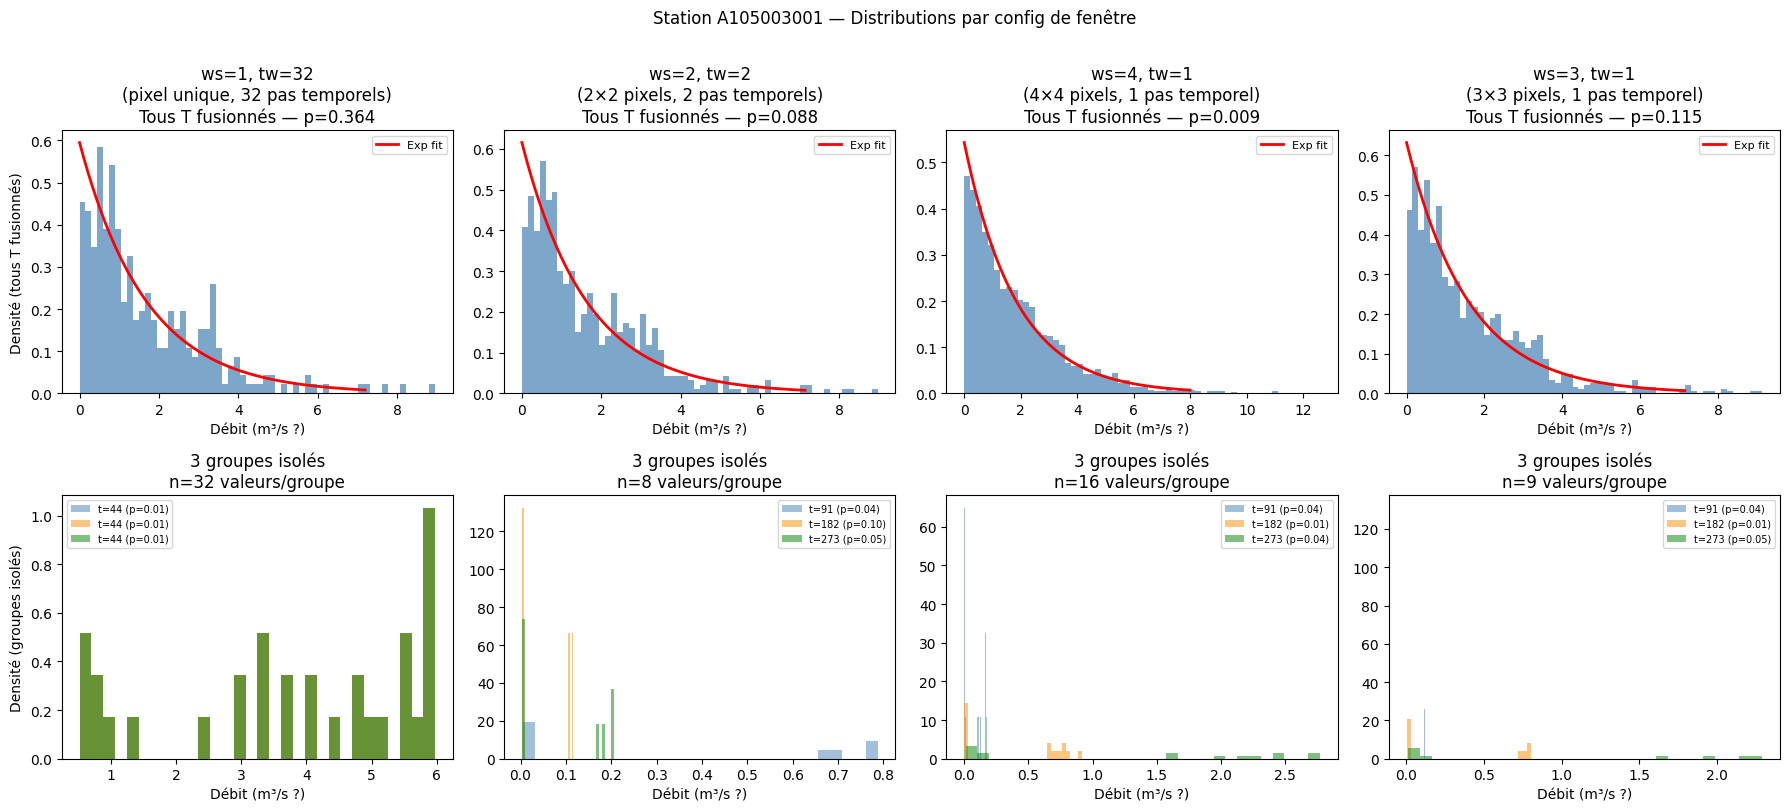

In [128]:
# ── Histogrammes pour comprendre la forme des distributions ─────────────────
# On compare ws=1/tw=1 (pixel pur), ws=1/tw=4, ws=5/tw=1, ws=5/tw=4

configs = [
    (1, 32,  "ws=1, tw=32\n(pixel unique, 32 pas temporels)"),
    (2,2,  "ws=2, tw=2\n(2×2 pixels, 2 pas temporels)"),
    (4, 1,  "ws=4, tw=1\n(4×4 pixels, 1 pas temporel)"),
    (3, 1,  "ws=3, tw=1\n(3×3 pixels, 1 pas temporel)"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Choisir quelques groupes temporels représentatifs (ex. début, milieu, fin de série)
window_ref = extract_window(data, lat_idx, lon_idx, 5, 4)
T_ref = window_ref.shape[0]
t_samples = [T_ref // 4, T_ref // 2, 3 * T_ref // 4]  # saisons différentes

for col, (ws, tw, label) in enumerate(configs):
    win = extract_window(data, lat_idx, lon_idx, ws, tw)
    if win is None:
        continue
    T = win.shape[0]

    # Ligne 0 : histogramme de tous les groupes temporels fusionnés
    all_vals = win.ravel()
    all_vals = all_vals[~np.isnan(all_vals)]
    all_vals = all_vals[all_vals > 2.5]  # Exclure les valeurs nulles ou négatives
    all_vals = all_vals - all_vals.min()  # Décaler pour test exponentiel

    ax = axes[0, col]
    ax.hist(all_vals, bins=60, density=True, alpha=0.7, color='steelblue')
    lam = 1.0 / np.mean(all_vals)
    x_fit = np.linspace(0, np.percentile(all_vals, 99), 200)
    ax.plot(x_fit, stats.expon.pdf(x_fit, 0, 1/lam), 'r-', lw=2, label='Exp fit')
    _, p_all = stats.kstest(all_vals, 'expon', args=(0, 1/lam))
    ax.set_title(f"{label}\nTous T fusionnés — p={p_all:.3f}")
    ax.legend(fontsize=8)

    # Ligne 1 : histogrammes de 3 groupes temporels isolés
    ax = axes[1, col]
    colors = ['steelblue', 'darkorange', 'green']
    ps = []
    for k, t_idx in enumerate(t_samples):
        if t_idx >= T:
            t_idx = T - 1
        x = win[t_idx].ravel()
        x = x[~np.isnan(x)]
        if len(x) < 3:
            continue
        lam_t = 1.0 / np.mean(x)
        _, p_t = stats.kstest(x, 'expon', args=(0, 1/lam_t))
        ps.append(p_t)
        ax.hist(x, bins=30, density=True, alpha=0.5, color=colors[k],
                label=f"t={t_idx} (p={p_t:.2f})")
    ax.set_title(f"3 groupes isolés\nn={len(x)} valeurs/groupe")
    ax.legend(fontsize=7)

axes[0, 0].set_ylabel("Densité (tous T fusionnés)")
axes[1, 0].set_ylabel("Densité (groupes isolés)")
for ax in axes.ravel():
    ax.set_xlabel("Débit (m³/s ?)")

plt.suptitle(f"Station {station['code_station']} — Distributions par config de fenêtre", y=1.01)
plt.tight_layout()
plt.show()


In [94]:
# ── Diagnostic : test KS sur X_train_raw en séparant les axes ────────────────
# X_train_raw[i]    → shape (T_steps, n_flat)   où n_flat = D_dim * W_dim * W_dim
# X_train_raw[i][j] → shape (n_flat,) = ravel de (D_dim, W_dim, W_dim)

alpha = 0.05

i0 = 0
flat_sample = X_train_raw[i0]               # (T_steps, n_flat)
T_steps, n_flat = flat_sample.shape

# Infer D_dim et W_dim à partir de T et du nb total de pas temporels NetCDF
#   T_steps = total_time / D_dim → D_dim = total_time / T_steps = 1460 / 365 = 4
D_dim = 1460 // T_steps                    # 4
W_dim = int(round((n_flat / D_dim) ** 0.5)) # 4  (car n_flat = D*W*W)
half_w = W_dim // 2

print(f"X_train_raw[0]: shape={flat_sample.shape}")
print(f"  -> D_dim={D_dim}, W_dim={W_dim}  (vérifié: {D_dim}×{W_dim}²={D_dim*W_dim**2} == {n_flat})")

results_ktest = {'A_ravel (D×W²={})'.format(n_flat): [],
                 'C_pixel_central (D={})'.format(D_dim): [],
                 'D_snap_spatial (W²={})'.format(W_dim**2): []}

key_A = list(results_ktest.keys())[0]
key_C = list(results_ktest.keys())[1]
key_D = list(results_ktest.keys())[2]

for j in range(T_steps):
    group_flat = flat_sample[j]                         # (n_flat,)
    group = group_flat.reshape(D_dim, W_dim, W_dim)    # (D, W, W)

    # A : ravel complet (comme dans le code original)
    x_A = group_flat[~np.isnan(group_flat)]
    if len(x_A) >= 5:
        _, p_A = stats.kstest(x_A, 'expon', args=(0, 1.0 / (1.0 / np.mean(x_A))))
        results_ktest[key_A].append(p_A)

    # C : pixel central, D valeurs temporelles
    x_C = group[:, half_w, half_w]
    x_C = x_C[~np.isnan(x_C)]
    if len(x_C) >= 5:
        _, p_C = stats.kstest(x_C, 'expon', args=(0, 1.0 / np.mean(x_C)))
        results_ktest[key_C].append(p_C)

    # D : snapshot spatial au pas t=0
    x_D = group[0].ravel()
    x_D = x_D[~np.isnan(x_D)]
    if len(x_D) >= 5:
        _, p_D = stats.kstest(x_D, 'expon', args=(0, 1.0 / np.mean(x_D)))
        results_ktest[key_D].append(p_D)

print(f"\n{'Option':<30} {'N testés':>9} {'Passent':>10} {'Taux':>8}")
print("-" * 60)
for key, ps_list in results_ktest.items():
    ps_arr = np.array(ps_list)
    n_pass = (ps_arr > alpha).sum()
    rate_val = n_pass / len(ps_arr) if len(ps_arr) > 0 else 0
    print(f"  {key:<28} {len(ps_arr):>9}  {n_pass:>6}/{len(ps_arr):<6}    {100*rate_val:>5.1f}%")

X_train_raw[0]: shape=(365, 64)
  -> D_dim=4, W_dim=4  (vérifié: 4×4²=64 == 64)

Option                          N testés    Passent     Taux
------------------------------------------------------------
  A_ravel (D×W²=64)                  365       0/365         0.0%
  C_pixel_central (D=4)                0       0/0           0.0%
  D_snap_spatial (W²=16)             365       0/365         0.0%


## Analyse 2 — Le pic proche de 0 : valeurs quasi-nulles de débit

Dans les histogrammes précédents, on observe un excès de valeurs dans [0, 0.1].  
Deux causes possibles :
- **Étiages** : débits très faibles mais réels (rivière proche de l'assèchement)
- **Artéfacts spatiaux** : pixels en bordure du domaine ou sur des zones terrestres non drainées

Ces valeurs proches de zéro créent une bimodalité incompatible avec la loi exponentielle (qui est unimodale avec un mode en 0 *lorsque λ est ajusté sur toutes les valeurs*).

La cellule suivante quantifie l'impact de ces valeurs sur l'ajustement exponentiel et compare le taux de passage avec et sans filtrage.

Seuil (m³/s)  | % valeurs < seuil | Taux KS pass (restantes) | n restant
--------------------------------------------------------------------------
  (aucun)     |      —            |  0.0000  (FAIL)              |  1460
  0.5         |   37.4%           |  0.5136  (PASS)              |  914
  1.0         |   51.6%           |  0.3271  (PASS)              |  707
  2.0         |   71.4%           |  0.2036  (PASS)              |  418
  5.0         |   94.5%           |  0.2241  (PASS)              |  81
  10.0        |   99.8%           |  trop peu de données (<5)    |  3


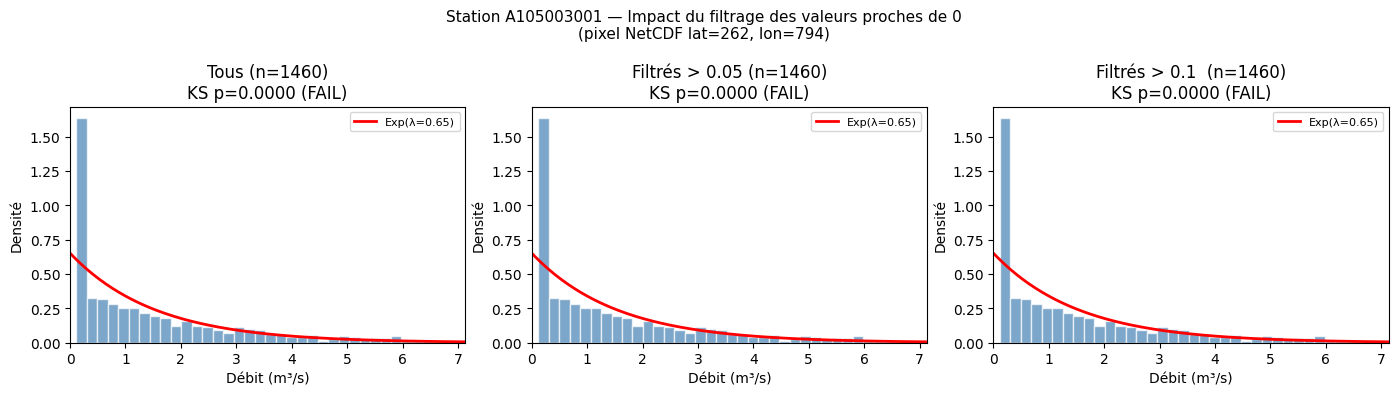

In [ ]:
# ── Analyse du pic proche de 0 sur la station 1 (NetCDF) ─────────────────────
# Utilise la série brute NetCDF (déjà chargée en cell 11 : data, lat_idx, lon_idx)

ts_raw = data[:, lat_idx, lon_idx].astype(float)
ts_raw[ts_raw < 0] = np.nan          # valeurs sentinelles négatives → NaN
ts_valid = ts_raw[~np.isnan(ts_raw)]

thresholds = [0.5, 1.0, 2.0, 5.0, 10.0]
print("Seuil (m³/s)  | % valeurs < seuil | Taux KS pass (restantes) | n restant")
print("-" * 74)

# Sans filtrage
lam0 = 1.0 / np.mean(ts_valid)
_, p0 = stats.kstest(ts_valid, 'expon', args=(0, 1/lam0))
print(f"  (aucun)     |      —            |  {p0:.4f}  ({'PASS' if p0>0.05 else 'FAIL'})              |  {len(ts_valid)}")

for thr in thresholds:
    frac_below = (ts_valid < thr).mean() * 100
    ts_filtered = ts_valid[ts_valid >= thr]
    ts_filtered = ts_filtered - ts_filtered.min()  # Décaler pour test exponentiel
    if len(ts_filtered) < 5:
        print(f"  {thr:<6}      | {frac_below:>6.1f}%           |  trop peu de données (<5)    |  {len(ts_filtered)}")
        continue
    lam_f = 1.0 / np.mean(ts_filtered)
    _, p_f = stats.kstest(ts_filtered, 'expon', args=(0, 1/lam_f))
    print(f"  {thr:<6}      | {frac_below:>6.1f}%           |  {p_f:.4f}  ({'PASS' if p_f>0.05 else 'FAIL'})              |  {len(ts_filtered)}")

# ── Figure : histogramme comparatif sans/avec filtrage ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (label, ts_plot) in zip(axes, [
    ("Tous (n={})".format(len(ts_valid)), ts_valid),
    ("Filtrés > 0.05 (n={})".format((ts_valid >= 0.05).sum()), ts_valid[ts_valid >= 0.05]),
    ("Filtrés > 0.1  (n={})".format((ts_valid >= 0.1).sum()),  ts_valid[ts_valid >= 0.1]),
]):

    ax.hist(ts_plot, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    if len(ts_plot) >= 5:
        lam_p = 1.0 / np.mean(ts_plot)
        x_range = np.linspace(0, ts_plot.max(), 300)
        ax.plot(x_range, lam_p * np.exp(-lam_p * x_range), 'r-', linewidth=2, label=f'Exp(λ={lam_p:.2f})')
        _, p_plot = stats.kstest(ts_plot, 'expon', args=(0, 1/lam_p))
        ax.set_title(f"{label}\nKS p={p_plot:.4f} ({'PASS' if p_plot>0.05 else 'FAIL'})")
    else:
        ax.set_title(label)
    ax.set_xlabel("Débit (m³/s)")
    ax.set_ylabel("Densité")
    ax.legend(fontsize=8)
    ax.set_xlim(0, np.percentile(ts_plot, 99) if len(ts_plot) > 0 else 10)

plt.suptitle(f"Station A105003001 — Impact du filtrage des valeurs proches de 0\n"
             f"(pixel NetCDF lat={lat_idx}, lon={lon_idx})", fontsize=11)
plt.tight_layout()
plt.show()

  Débit min observed   : 0.251 m³/s
  n                    : 1040

  Modèle               |  KS stat  |  p-value  |  Décision
  Exp(0, 1/λ) - actuel   0.1153      0.0000     FAIL
  Exp(loc=min, 1/λ)      0.0231      0.6287     PASS
  Exp(loc_MLE, scale_MLE) 0.0231      0.6287     PASS
    -> loc_MLE            0.251 m³/s (≈ min = 0.251)
    -> scale_MLE=1/λ      1.840 m³/s → λ = 0.543


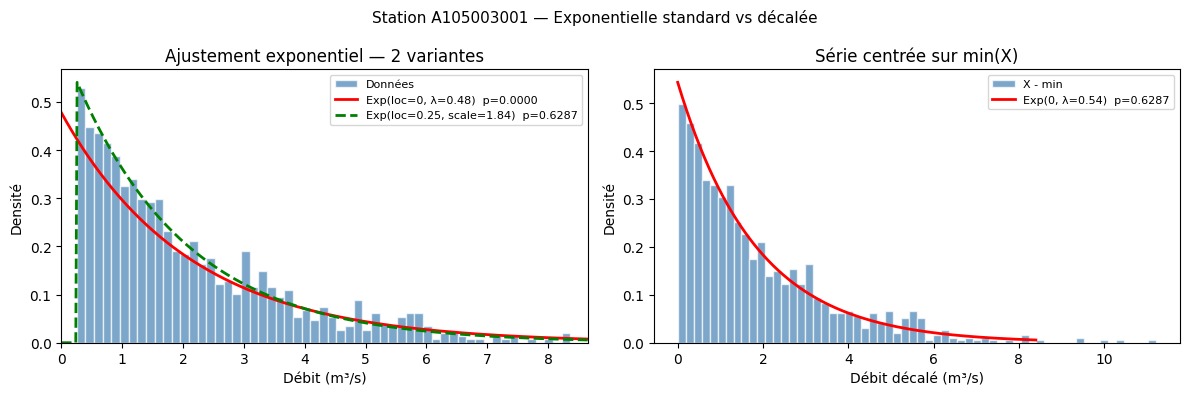

In [108]:
# ── Est-ce une exponentielle DÉCALÉE ? ───────────────────────────────────────
# Le minimum de la série est 0.116 m³/s (débit de base → débit jamais nul).
# L'ajustement standard expon(loc=0) sous-estime toute la masse en [0, min].
# Un modèle plus réaliste : X - min_x ~ Exp(λ) (exponentielle décalée).

x = ts_valid.copy()
x = x[x > 0.25]
x_min = x.min()
x_shift = x - x_min          # centre sur 0
# Test KS sur la série décalée
lam_shift = 1.0 / np.mean(x_shift)
ks_stat_shifted, p_shifted = stats.kstest(x_shift, 'expon', args=(0, 1/lam_shift))

# Test KS sur la série originale (loc=0, comme dans le code actuel)
lam_orig = 1.0 / np.mean(x)
ks_stat_orig, p_orig = stats.kstest(x, 'expon', args=(0, 1/lam_orig))

# Test KS en laissant scipy estimer loc et scale librement (2 paramètres)
loc_mle, scale_mle = stats.expon.fit(x)
ks_stat_mle, p_mle = stats.kstest(x, 'expon', args=(loc_mle, scale_mle))

print(f"  Débit min observed   : {x_min:.3f} m³/s")
print(f"  n                    : {len(x)}")
print()
print(f"  Modèle               |  KS stat  |  p-value  |  Décision")
print(f"  {'Exp(0, 1/λ) - actuel':<22} {ks_stat_orig:.4f}      {p_orig:.4f}     {'PASS' if p_orig>0.05 else 'FAIL'}")
print(f"  {'Exp(loc=min, 1/λ)':<22} {ks_stat_shifted:.4f}      {p_shifted:.4f}     {'PASS' if p_shifted>0.05 else 'FAIL'}")
print(f"  {'Exp(loc_MLE, scale_MLE)':<22} {ks_stat_mle:.4f}      {p_mle:.4f}     {'PASS' if p_mle>0.05 else 'FAIL'}")
print(f"  {'  -> loc_MLE':<22}  {loc_mle:.3f} m³/s (≈ min = {x_min:.3f})")
print(f"  {'  -> scale_MLE=1/λ':<22}  {scale_mle:.3f} m³/s → λ = {1/scale_mle:.3f}")

# ── Figure : comparaison des 3 ajustements ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(x_min, np.percentile(x, 99.5), 60)
axes[0].hist(x, bins=bins, density=True, color='steelblue', alpha=0.7, edgecolor='white', label='Données')
xr = np.linspace(0, bins[-1], 400)
axes[0].plot(xr, lam_orig * np.exp(-lam_orig * xr), 'r-', lw=2, label=f'Exp(loc=0, λ={lam_orig:.2f})  p={p_orig:.4f}')
axes[0].plot(xr, stats.expon.pdf(xr, loc=loc_mle, scale=scale_mle), 'g--', lw=2,
             label=f'Exp(loc={loc_mle:.2f}, scale={scale_mle:.2f})  p={p_mle:.4f}')
axes[0].set_xlim(0, bins[-1])
axes[0].set_xlabel("Débit (m³/s)")
axes[0].set_ylabel("Densité")
axes[0].set_title("Ajustement exponentiel — 2 variantes")
axes[0].legend(fontsize=8)

# Série décalée
xr_shift = np.linspace(0, np.percentile(x_shift, 99.5), 400)
axes[1].hist(x_shift, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white', label='X - min')
axes[1].plot(xr_shift, lam_shift * np.exp(-lam_shift * xr_shift), 'r-', lw=2,
             label=f'Exp(0, λ={lam_shift:.2f})  p={p_shifted:.4f}')
axes[1].set_xlabel("Débit décalé (m³/s)")
axes[1].set_ylabel("Densité")
axes[1].set_title("Série centrée sur min(X)")
axes[1].legend(fontsize=8)

plt.suptitle("Station A105003001 — Exponentielle standard vs décalée", fontsize=11)
plt.tight_layout()
plt.show()

## Analyse 3 — Étude multi-stations : quel fenêtrage respecte le mieux le modèle ?

On sélectionne 10 stations (réparties sur les 3 régimes PC/PN/PM) et on calcule le taux de passage KS  
pour plusieurs configurations (window_size × time_window), afin de choisir un compromis  
entre **puissance du test** (grand n) et **homogénéité spatio-temporelle** (petite fenêtre).

In [106]:
# ── Chargement des 10 stations (3-4 par régime) ──────────────────────────────
# Les variables suivantes sont supposées disponibles (cell 11) :
#   df_stations, data, lat_coords, lon_coords,
#   extract_window, find_nearest_pixel, lambert93_to_wgs84

# Charger le CSV si df_stations n'est pas en mémoire
import importlib.util, sys

repo_root = Path("..").resolve()
module_path = repo_root / "src" / "data_generator" / "Explore_2_dataset" / "build_classification_dataset.py"
spec = importlib.util.spec_from_file_location("build_classification_dataset", module_path)
bcd = importlib.util.module_from_spec(spec)
spec.loader.exec_module(bcd)

extract_window        = bcd.extract_window
find_nearest_pixel    = bcd.find_nearest_pixel
lambert93_to_wgs84    = bcd.lambert93_to_wgs84

import pandas as pd
NC_PATH  = "/home/mgallet/Documents/Dataset/RIVER_DISCHARGES/c7491e060d94c97212f0fe7ebcff57f0/data_version-5.nc"
CSV_PATH = str(repo_root / "src" / "data_generator" / "Explore_2_dataset" / "stations_regimes_explore2.csv")
df_stations = pd.read_csv(CSV_PATH, sep=",")
print(f"CSV chargé : {len(df_stations)} stations, régimes={df_stations['regime_code'].value_counts().to_dict()}")

# Sélection équilibrée : 3-4 stations par régime
REGIME_QUOTA = 4
selected = (df_stations
            .groupby('regime_code', group_keys=False)
            .apply(lambda g: g.head(REGIME_QUOTA)))
selected = selected.reset_index(drop=True)
print(f"\n{len(selected)} stations sélectionnées :")
print(selected[['code_station', 'nom_station', 'regime_code', 'X_Lambert93', 'Y_Lambert93']].to_string(index=False))

CSV chargé : 611 stations, régimes={'PC': 407, 'PN': 115, 'NP': 51, 'NG': 28, 'PM': 10}

20 stations sélectionnées :
code_station                                      nom_station regime_code  X_Lambert93  Y_Lambert93
  O036251001            Le Salat a Soueix-Rogalle[Kercabanac]          NG     553998.0    6202681.0
  O125251001                                  L Ariege a Foix          NG     586417.0    6208473.0
  Q010001001         L Adour [Adour Seul] a Aste [Pont Daste]          NG     468731.0    6219471.0
  Q010002500         L Adour [Adour+Canal]a Aste [Pont Daste]          NG     468731.0    6219471.0
  K051301001                    L Ance Du Nord a Sauvessanges          NP     769780.0    6475990.0
  K053000101              L Ance a Saint-Julien-Dance[Laprat]          NP     773617.0    6468073.0
  K222302001 L Ance Du Sud a Saint-Prejet-Dallier[Chambonnet]          NP     749842.0    6422209.0
  K222303001             L Ance Du Sud a Saint-Prejet-Dallier          NP     74926

In [ ]:
def ks_pass_rate(data, lat_idx, lon_idx, window_size, time_window,
                 alpha=0.05, threshold=10.0):
    """
    Pour une station donnée, extrait la fenêtre complète puis teste chaque
    groupe temporel (axe T) : est-ce que les D*W*W valeurs (après seuillage)
    suivent une loi exponentielle décalée ?

    Paramètres
    ----------
    threshold : float
        Multiplicateur de x.min() par groupe. On garde x > threshold * x.min()
        pour éliminer le débit de base (faibles valeurs structurelles).

    Retour
    ------
    (mean_p, rate, passed, tested, last_x)
        mean_p  : moyenne des p-values des groupes qui passent (np.nan si aucun)
        rate    : proportion de groupes qui passent le test KS (p > alpha)
        passed  : nombre de groupes avec p > alpha
        tested  : nombre de groupes testés (n >= 5 après filtrage)
        last_x  : derniers échantillons testés (pour débogage)
    """
    window = extract_window(data, lat_idx, lon_idx, window_size, time_window)
    if window is None:
        return np.nan, 0, 0, np.array([])

    passed, tested = 0, 0
    p_values = []
    last_x = np.array([])

    for t in range(window.shape[0]):
        x = window[t].ravel()
        x = x[~np.isnan(x)]
        x = x[x > threshold * x.min()]   # garder seulement le débit au-delà du base flow
        if len(x) < 5:
            continue
        x = x - x.min()                  # décalage → exponentielle centrée sur 0
        lam = 1.0 / np.mean(x)
        _, p = stats.kstest(x, 'expon', args=(0, 1.0 / lam))
        tested += 1
        last_x = x
        if p > alpha:
            passed += 1
            p_values.append(p)

    mean_p = np.mean(p_values) if p_values else np.nan
    rate = passed / tested if tested > 0 else np.nan
    return mean_p, rate, passed, tested, last_x

In [153]:
# ── Grille KS multi-stations × seuils ────────────────────────────────────────
# Pour chaque station × config (ws, tw) × threshold, calcule la p-value KS moyenne.

from tqdm import tqdm

MIN_N           = 20
window_sizes    = [2, 3, 4]
time_windows    = [2]#,3, 4, 8]
thresholds_grid = [1, 5, 10, 25, 50]   # multiplicateurs de x.min() par groupe

n_per_config = {(ws, tw): ws**2 * tw for ws in window_sizes for tw in time_windows}

selected_valid = selected.dropna(subset=['X_Lambert93', 'Y_Lambert93']).copy()
print(f"Stations valides : {len(selected_valid)}")

records = []
for _, row in tqdm(selected_valid.iterrows(), total=len(selected_valid)):
    lon_s, lat_s = lambert93_to_wgs84(row['X_Lambert93'], row['Y_Lambert93'])
    li, loni = find_nearest_pixel(lat_s, lon_s, lat_coords, lon_coords)

    for ws in window_sizes:
        for tw in time_windows:
            n = n_per_config[(ws, tw)]
            if n < MIN_N:
                continue
            for thr in thresholds_grid:
                rate, passed, tested, _ = ks_pass_rate(data, li, loni, ws, tw,
                                                        threshold=thr)
                records.append({
                    'code_station': row['code_station'],
                    'regime':       row['regime_code'],
                    'ws':           ws,
                    'tw':           tw,
                    'n_per_group':  n,
                    'threshold':    thr,
                    'rate':         rate,
                    'passed':       passed,
                    'tested':       tested,
                })

df_grid = pd.DataFrame(records)
print(f"\n{len(df_grid)} mesures calculées "
      f"({len(selected_valid)} stations × {len([c for c in n_per_config if n_per_config[c]>=MIN_N])} configs × {len(thresholds_grid)} seuils).\n")

summary = (df_grid.groupby(['ws', 'tw', 'n_per_group', 'threshold'])['rate']
           .agg(mean='mean', std='std', n_stations='count')
           .round(3)
           .reset_index())
summary['mean_%'] = (summary['mean'] * 100).round(1)
summary['std_%']  = (summary['std']  * 100).round(1)
print(summary[['ws', 'tw', 'n_per_group', 'threshold', 'mean_%', 'std_%']].to_string(index=False))

Stations valides : 20


100%|██████████| 20/20 [01:07<00:00,  3.35s/it]


100 mesures calculées (20 stations × 1 configs × 5 seuils).

 ws  tw  n_per_group  threshold  mean_%  std_%
  4   2           32          1    13.7    8.8
  4   2           32          5    18.0   11.8
  4   2           32         10    21.8   13.8
  4   2           32         25    24.7   12.3
  4   2           32         50    28.5   11.9


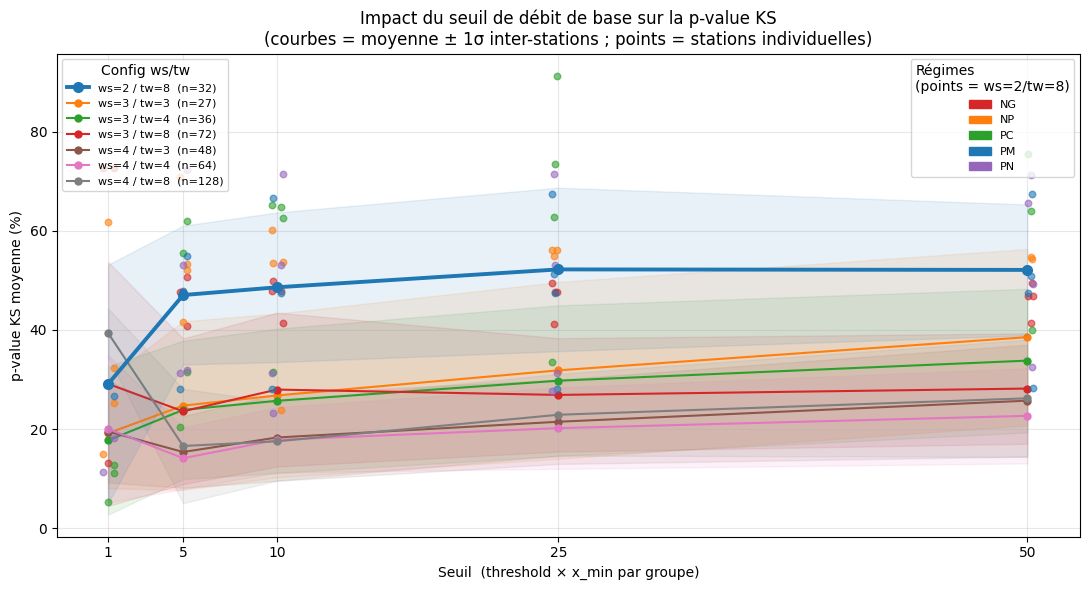

In [149]:
# ── Visualisation : impact du seuil sur la p-value KS par config ─────────────
# Une courbe par (ws, tw), bande ±1σ inter-stations ; points individuels sur la
# meilleure config, colorés par régime.

palette_regime = {'NG': '#d62728', 'NP': '#ff7f0e', 'PC': '#2ca02c',
                  'PM': '#1f77b4', 'PN': '#9467bd'}

thresholds_grid = sorted(df_grid['threshold'].unique())

# Meilleure config (plus haut taux moyen toutes configs/seuils confondus)
best_config_row = df_grid.groupby(['ws', 'tw'])['rate'].mean().idxmax()
best_ws_p, best_tw_p = best_config_row

fig, ax = plt.subplots(figsize=(11, 6))

color_cycle = plt.cm.tab10(np.linspace(0, 1, len(window_sizes) * len(time_windows)))
ci = 0

for ws in window_sizes:
    for tw in time_windows:
        n = n_per_config.get((ws, tw), 0)
        if n < MIN_N:
            continue
        subset = df_grid[(df_grid['ws'] == ws) & (df_grid['tw'] == tw)]
        thr_mean = subset.groupby('threshold')['rate'].mean() * 100
        thr_std  = subset.groupby('threshold')['rate'].std()  * 100
        color = color_cycle[ci]; ci += 1
        lw = 2.8 if (ws == best_ws_p and tw == best_tw_p) else 1.5
        zorder = 5 if (ws == best_ws_p and tw == best_tw_p) else 2
        ax.plot(thr_mean.index, thr_mean.values, 'o-', color=color,
                label=f"ws={ws} / tw={tw}  (n={n})",
                linewidth=lw, markersize=5 + 2 * (ws == best_ws_p and tw == best_tw_p),
                zorder=zorder)
        ax.fill_between(thr_mean.index,
                        (thr_mean - thr_std).clip(lower=0).values,
                        (thr_mean + thr_std).clip(upper=100).values,
                        alpha=0.10, color=color, zorder=zorder - 1)

# Points individuels : meilleure config, colorés par régime
df_best_plot = df_grid[(df_grid['ws'] == best_ws_p) & (df_grid['tw'] == best_tw_p)]
for thr in thresholds_grid:
    slice_thr = df_best_plot[df_best_plot['threshold'] == thr]
    for regime in slice_thr['regime'].unique():
        vals = slice_thr[slice_thr['regime'] == regime]['rate'].values * 100
        jitter = (np.random.default_rng(int(thr)).random(len(vals)) - 0.5) * 0.7
        ax.scatter(thr + jitter, vals,
                   color=palette_regime.get(regime, 'gray'),
                   s=22, alpha=0.6, zorder=4)

# Légendes
handles_cfg, _ = ax.get_legend_handles_labels()
legend_cfg = ax.legend(handles=handles_cfg, fontsize=8,
                       title='Config ws/tw', loc='upper left')
ax.add_artist(legend_cfg)

from matplotlib.patches import Patch
regime_handles = [Patch(color=c, label=r)
                  for r, c in palette_regime.items()
                  if r in df_grid['regime'].values]
ax.legend(handles=regime_handles, fontsize=8, loc='upper right',
          title=f'Régimes\n(points = ws={best_ws_p}/tw={best_tw_p})')

ax.set_xlabel("Seuil  (threshold × x_min par groupe)")
ax.set_ylabel("p-value KS moyenne (%)")
ax.set_title("Impact du seuil de débit de base sur la p-value KS\n"
             "(courbes = moyenne ± 1σ inter-stations ; points = stations individuelles)")
ax.set_xticks(thresholds_grid)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  68 out of  80 | elapsed:  8.0min remaining:  1.4min
[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:  8.7min finished


960 lignes : 20 stations × 4 configs × 12 seuils

── Seuil minimal (×x_min) pour mean_p > 5 % ────────────────────────────
regime  ws  tw  min_thr (×x_min)  mean_p@thr (%)  pass_pct@thr (%)  fenêtres_testées  fenêtres_passées
    NG   3   8                 2             8.7               0.8             182.0               1.5
    NG   4   8                 5             6.9               0.3             182.0               0.5
    NG   4   2                 1             7.3               0.1             730.0               1.0
    NG   2   8                 1            52.8               1.2             182.0               2.2
    NP   3   8                 1            35.0               2.5             182.0               4.5
    NP   4   8                 1            39.4               1.5             182.0               2.8
    NP   4   2                 1            19.6              18.2             730.0             132.8
    NP   2   8                 1            33.6     

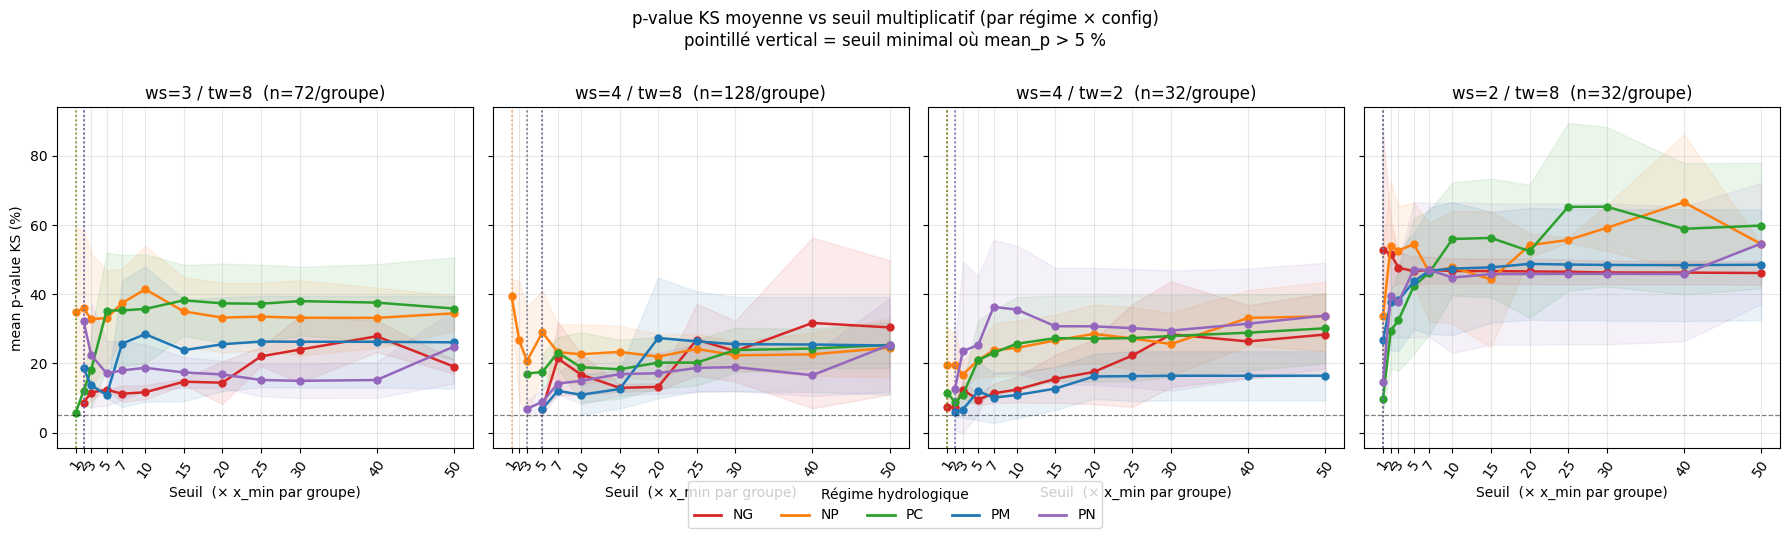

In [155]:
# ── KS itératif windowed : seuil optimal par classe ───────────────────────────
# Parallélisé par joblib sur (station × config ws/tw).
# Pour chaque régime × config → seuil multiplicatif minimal tel que mean_p > 5 %.

from joblib import Parallel, delayed
from matplotlib.lines import Line2D

# ─── Paramètres ───────────────────────────────────────────────────────────────
configs_test   = [(3, 8), (4, 8), (4, 2), (2, 8)]
thr_candidates = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30, 40, 50]

palette_regime = {'NG': '#d62728', 'NP': '#ff7f0e', 'PC': '#2ca02c',
                  'PM': '#1f77b4', 'PN': '#9467bd'}

# ─── Tâche unitaire : station × config × tous les seuils ─────────────────────
def _ks_task(row_dict, ws, tw):
    lon_s, lat_s = lambert93_to_wgs84(row_dict['X_Lambert93'], row_dict['Y_Lambert93'])
    li, loni     = find_nearest_pixel(lat_s, lon_s, lat_coords, lon_coords)
    records = []
    for thr in thr_candidates:
        rate, passed, tested, _ = ks_pass_rate(data, li, loni, ws, tw, threshold=thr)
        records.append({
            'code_station': row_dict['code_station'],
            'regime':       row_dict['regime_code'],
            'ws': ws, 'tw': tw,
            'threshold':    thr,
            'rate':         rate,                                       # mean p-value fenêtres passées
            'passed':       passed,
            'tested':       tested,
            'pass_pct':     passed / tested if tested > 0 else np.nan, # fraction de fenêtres passées
        })
    return records

# ─── Parallélisation (threads – partage mémoire, numpy/scipy libèrent le GIL) ─
rows_list = [row.to_dict() for _, row in selected_valid.iterrows()]

flat_results = Parallel(n_jobs=-1, verbose=3, prefer='threads')(
    delayed(_ks_task)(row_dict, ws, tw)
    for row_dict in rows_list
    for ws, tw in configs_test
)

df_ks_thr = pd.DataFrame([rec for sublist in flat_results for rec in sublist])
print(f"{len(df_ks_thr)} lignes : {len(selected_valid)} stations × "
      f"{len(configs_test)} configs × {len(thr_candidates)} seuils\n")

# ─── Agrégation par régime × config × seuil ───────────────────────────────────
agg = (df_ks_thr
       .groupby(['regime', 'ws', 'tw', 'threshold'])
       .agg(
           mean_rate   = ('rate',     'mean'),
           std_rate    = ('rate',     'std'),
           mean_pct    = ('pass_pct', 'mean'),
           mean_tested = ('tested',   'mean'),
           mean_passed = ('passed',   'mean'),
       )
       .reset_index())

# ─── Seuil minimal tel que mean_p > 5 % (par régime × config) ────────────────
TARGET_P = 0.05
rows_summary = []
for regime in sorted(agg['regime'].unique()):
    for ws, tw in configs_test:
        sub = (agg[(agg['regime'] == regime) & (agg['ws'] == ws) & (agg['tw'] == tw)]
               .sort_values('threshold'))
        passing = sub[sub['mean_rate'] > TARGET_P]
        if passing.empty:
            rows_summary.append({
                'regime': regime, 'ws': ws, 'tw': tw,
                'min_thr (×x_min)':  np.nan,
                'mean_p@thr (%)':    np.nan,
                'pass_pct@thr (%)':  np.nan,
                'fenêtres_testées':  np.nan,
                'fenêtres_passées':  np.nan,
            })
        else:
            best = passing.iloc[0]   # premier seuil (le plus bas) où mean_p > 5 %
            rows_summary.append({
                'regime': regime, 'ws': ws, 'tw': tw,
                'min_thr (×x_min)':  int(best['threshold']),
                'mean_p@thr (%)':    round(best['mean_rate'] * 100, 1),
                'pass_pct@thr (%)':  round(best['mean_pct']  * 100, 1),
                'fenêtres_testées':  round(best['mean_tested'], 1),
                'fenêtres_passées':  round(best['mean_passed'], 1),
            })

df_summary_thr = pd.DataFrame(rows_summary)
print("── Seuil minimal (×x_min) pour mean_p > 5 % ────────────────────────────")
print(df_summary_thr.to_string(index=False))

# ─── Figure : p-value moyenne vs seuil par régime × config ────────────────────
fig, axes = plt.subplots(1, len(configs_test), figsize=(18, 5), sharey=True)

for ax_i, (ws, tw) in enumerate(configs_test):
    ax = axes[ax_i]
    sub_cfg = agg[(agg['ws'] == ws) & (agg['tw'] == tw)]
    for regime in sorted(sub_cfg['regime'].unique()):
        sub_r = sub_cfg[sub_cfg['regime'] == regime].sort_values('threshold')
        c = palette_regime.get(regime, 'gray')
        ax.plot(sub_r['threshold'], sub_r['mean_rate'] * 100,
                'o-', color=c, linewidth=1.8, markersize=5, label=regime)
        ax.fill_between(sub_r['threshold'],
                        ((sub_r['mean_rate'] - sub_r['std_rate']) * 100).clip(lower=0),
                        ((sub_r['mean_rate'] + sub_r['std_rate']) * 100).clip(upper=100),
                        alpha=0.09, color=c)
        # seuil optimal (ligne verticale pointillée)
        opt = df_summary_thr[
            (df_summary_thr['regime'] == regime) &
            (df_summary_thr['ws'] == ws) &
            (df_summary_thr['tw'] == tw)
        ]
        if not opt.empty and not pd.isna(opt.iloc[0]['min_thr (×x_min)']):
            ax.axvline(opt.iloc[0]['min_thr (×x_min)'],
                       color=c, linestyle=':', linewidth=1.2, alpha=0.7)

    ax.axhline(5, color='k', linestyle='--', linewidth=0.9, alpha=0.5)
    ax.set_title(f"ws={ws} / tw={tw}  (n={ws**2*tw}/groupe)")
    ax.set_xlabel("Seuil  (× x_min par groupe)")
    if ax_i == 0:
        ax.set_ylabel("mean p-value KS (%)")
    ax.set_xticks(thr_candidates)
    ax.tick_params(axis='x', labelrotation=55)
    ax.grid(True, alpha=0.3)

handles = [Line2D([0], [0], color=c, linewidth=2, label=r)
           for r, c in palette_regime.items()
           if r in agg['regime'].values]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=10,
           title='Régime hydrologique', bbox_to_anchor=(0.5, -0.04))
fig.suptitle("p-value KS moyenne vs seuil multiplicatif (par régime × config)\n"
             "pointillé vertical = seuil minimal où mean_p > 5 %",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()